# Business Understanding (Entendimento do Negócio)


### 1. Contexto do Negócio
No cenário varejista atual, otimizar os investimentos em marketing e maximizar o Retorno sobre o Investimento (ROI) em cada cliente é fundamental para a competitividade. A empresa possui uma base de clientes diversificada, com diferentes níveis de renda, estruturas familiares e preferências de consumo. Tratar toda essa base de forma homogênea, com campanhas de "marketing de massa", resulta em desperdício de orçamento e comunicação ineficiente.

### 2. O Problema de Negócio
Atualmente, as ofertas promocionais e o esforço de marketing não estão perfeitamente alinhados com o comportamento real de compra dos consumidores. O envio de campanhas genéricas gera:
* Baixas taxas de aceitação (conversão) nas campanhas de marketing.
* Custos operacionais desnecessários ao impactar clientes sem propensão de compra para determinados produtos.
* Perda de oportunidades de aumento de ticket médio (*cross-selling* e *up-selling*), já que não há um direcionamento claro (ex: ofertar carnes premium ou vinhos para o perfil correto).

### 3. Objetivos do Projeto (Business Goals)
O objetivo principal deste projeto de Ciência de Dados é **transicionar de uma abordagem de marketing de massa para um marketing de precisão**. Para isso, aplicaremos técnicas de aprendizado de máquina não supervisionado para:
* **Segmentar a base de clientes** em clusters distintos e homogêneos, baseados em características demográficas, histórico de compras e engajamento.
* **Mapear o perfil de consumo** de cada grupo (ex: clientes de alto valor, caçadores de promoções, compradores frequentes de loja física vs. web).
* **Fornecer inteligência acionável** para que a equipe comercial e de marketing possa desenhar ofertas altamente personalizadas.

### 4. Critérios de Sucesso
O projeto será considerado um sucesso, do ponto de vista de negócios, se os *insights* gerados pelos clusters permitirem:
* **Aumento da Taxa de Conversão:** Identificar quais perfis têm maior probabilidade de aceitar a próxima campanha (variável `Response`).
* **Otimização de Custos:** Redução do custo de envio de campanhas ao focar apenas nos clusters com real aderência à oferta.
* **Estratégia de Canal:** Direcionar o esforço de vendas para o canal preferido de cada segmento (lojas físicas, site ou catálogo).




## Data Understanding

Nesta etapa, o foco é compreender a estrutura, a origem e a qualidade dos dados disponíveis antes de iniciar qualquer modelagem. O conjunto de dados utilizado é o **Customer Personality Analysis**, que contém informações detalhadas sobre o comportamento de compra e o perfil demográfico de clientes de uma empresa varejista.

### 1. Fonte e Estrutura dos Dados
* **Origem:** Plataforma Kaggle (dataset *Customer Personality Analysis*).
* **Formato:** Arquivo tabular estático (`.csv`).
* **Volume:** Aproximadamente 2.240 registros (linhas) e 29 atributos (colunas). Cada registro representa um cliente único e seu histórico com a empresa.

### 2. Dicionário de Dados
As 29 variáveis originais foram agrupadas em quatro categorias lógicas para facilitar o entendimento analítico e comercial:

**A. Perfil Demográfico**
* `ID`: Identificador único do cliente.
* `Year_Birth`: Ano de nascimento do cliente.
* `Education`: Nível máximo de escolaridade atingido.
* `Marital_Status`: Estado civil atual.
* `Income`: Renda anual do núcleo familiar.
* `Kidhome` / `Teenhome`: Quantidade de crianças pequenas e adolescentes na residência, respectivamente.

**B. Comportamento e Interação (Canais)**
* `Dt_Customer`: Data em que o cliente se cadastrou na base da empresa.
* `Recency`: Recência (número de dias desde a última compra realizada).
* `NumWebVisitsMonth`: Número de visitas ao site da empresa no último mês.
* `NumWebPurchases`: Quantidade de compras realizadas pelo site.
* `NumCatalogPurchases`: Quantidade de compras feitas através de catálogos.
* `NumStorePurchases`: Quantidade de compras realizadas presencialmente na loja física.

**C. Histórico de Consumo (Valores gastos nos últimos 2 anos)**
* `MntWines`: Valor gasto na categoria de Vinhos.
* `MntFruits`: Valor gasto na categoria de Frutas.
* `MntMeatProducts`: Valor gasto na categoria de Carnes.
* `MntFishProducts`: Valor gasto na categoria de Pescados.
* `MntSweetProducts`: Valor gasto na categoria de Doces.
* `MntGoldProds`: Valor gasto em produtos Premium/Ouro.

**D. Engajamento em Marketing e Retenção**
* `AcceptedCmp1` a `AcceptedCmp5`: Indicadores binários (1 = Sim, 0 = Não) de aceitação das ofertas nas campanhas promocionais de 1 a 5.
* `Response`: Indicador binário de aceitação na última campanha (pode ser utilizado como variável alvo em futuras modelagens supervisionadas).
* `Complain`: Indicador binário (1 = Sim, 0 = Não) se o cliente registrou alguma reclamação oficial nos últimos 2 anos.



### Setup

In [1]:
#Data Wraling
import pandas as pd
import numpy as np

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

#Configuração básica de estilo para o Seaborn/Matplotlib
sns.set_theme(style="whitegrid")

#Remove warnings
import warnings
warnings.filterwarnings("ignore") # Evita poluição visual com alertas do Scikit-Learn


#Pré-processamento e reduduçãio de dimensionalidade
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

#Modelling
from sklearn.cluster import KMeans

#Avaliação visual e métricas
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_score

In [2]:
#Load data 
df = pd.read_csv('../data/raw/customer_segmentation.csv')

In [3]:
#Primeiras linhas 
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
#Infos gerais 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
#Veficando nulos 
df.isnull().sum()

#Porcentagem de nulos 
df.isnull().sum() / len(df) * 100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

In [6]:
#Verificando dados duplicado 
df[df.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


In [7]:
#Formato dos dados 
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

* Vamos converter a coluna Dt_Customer para o formato Date Time.

* Também vamos optar por converter a nossa coluna 'ID' em índice, já que ela é apenas um identificador

* E por ultimo iremos remover as colunas Z_CostContact e Z_Revenue, pois não existem variação de valores nelas (todos clientes com valores 3 e 11, respectivamente).

## Data Cleaning

In [8]:
#Removendo nulos da coluna Income 
df.dropna(subset = 'Income', inplace = True)

In [9]:
#Tranformando a coluna Dt_Customer para o formato date time 
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format= '%d-%m-%Y')

#Tranformando a coluna ID em índice 
df = df.set_index('ID')

#Excluindo as colunas com variança zero 
df = df.drop(columns = ['Z_CostContact', 'Z_Revenue'])

#Verificando a estrutura 
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 5524 to 9405
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Year_Birth           2216 non-null   int64         
 1   Education            2216 non-null   str           
 2   Marital_Status       2216 non-null   str           
 3   Income               2216 non-null   float64       
 4   Kidhome              2216 non-null   int64         
 5   Teenhome             2216 non-null   int64         
 6   Dt_Customer          2216 non-null   datetime64[us]
 7   Recency              2216 non-null   int64         
 8   MntWines             2216 non-null   int64         
 9   MntFruits            2216 non-null   int64         
 10  MntMeatProducts      2216 non-null   int64         
 11  MntFishProducts      2216 non-null   int64         
 12  MntSweetProducts     2216 non-null   int64         
 13  MntGoldProds         2216 non-null   int64    

### Feature Engineer

O K-Means (algoritmo que usaremos) é um modelo matemático literal. Ele agrupa clientes medindo a "distância" entre os números.

Problema dos dados brutos: O algoritmo não sabe o que é o ano 1988, ele apenas vê um número grande. Ele não sabe que quem comprou 10 vezes na Web e 5 na Loja fez 15 compras no total. Se deixarmos os dados fragmentados, o algoritmo perde a "visão do todo".

A Solução (Feature Engineering): Nós mastigamos essa informação. Em vez de dar ao modelo o Ano de Nascimento, damos a Idade (que é muito mais representativa do ciclo de vida). Em vez de dar os gastos isolados de vinho, carne e frutas, somamos tudo e criamos o Gasto_Total para indicar de forma clara e direta: "este é um cliente de alto valor" ou "este é um cliente que gasta pouco".


In [10]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
ID,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,0,0,0,0,0,1
2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,0,0,0,0,0
4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,0,0,0,0,0
6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,0,0,0,0,0
5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,0,0,0,0,0


In [11]:
###Criando a idade atual do cliente

#Primeiro pegamos o ano mais recente de cadastro como referencia 
ano_maximo = df['Dt_Customer'].dt.year.max()

#Agora criamos a coluna idade 
df['Idade'] = ano_maximo - df['Year_Birth']


In [12]:
### Gasto total (ticket)

#Vamos somar todas as categorias de produtos para ter o total de compra por cliente 
df['Gasto_Total'] = (df['MntWines'] + df['MntFruits'] +
                     df['MntMeatProducts'] + df['MntFishProducts'] +
                     df['MntSweetProducts'] + df['MntGoldProds'] )

In [13]:
### Total de filhos em casa 

#Crianças e adolescentes vão ser iguais 
df['Total_Filhos'] = df['Kidhome'] + df['Teenhome']

In [14]:
### Tempo de cliente (fidelidade / maturidade)

#Calcular a diferença em dias entre a data de cadastro mais recente e a data do cliente
ano_referencia = df['Dt_Customer'].max()
df['Tempo_Cliente_Dias'] = (ano_referencia - df['Dt_Customer']).dt.days

In [15]:
### Total de compras 

#Vamos somar o volume/quantidade dew compras, independende de qual canal foi utilizado 
df['Total_Compras'] = (df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumWebPurchases'])


In [16]:
### Total de campanhas aceitas 

#Consolida a propensão do cliente a aceitar as campanhas de marketing
df['Total_Campanhas_Aceitas'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + 
                                 df['AcceptedCmp3'] + df['AcceptedCmp4'] + 
                                 df['AcceptedCmp5'] + df['Response'])

In [17]:
#Visualizando as novas colunas geradas
print(df[['Idade', 'Gasto_Total', 'Total_Filhos', 'Tempo_Cliente_Dias', 'Total_Compras', 'Total_Campanhas_Aceitas']].head())

      Idade  Gasto_Total  Total_Filhos  Tempo_Cliente_Dias  Total_Compras  \
ID                                                                          
5524     57         1617             0                 663             22   
2174     60           27             2                 113              4   
4141     49          776             0                 312             20   
6182     30           53             1                 139              6   
5324     33          422             1                 161             14   

      Total_Campanhas_Aceitas  
ID                             
5524                        1  
2174                        0  
4141                        0  
6182                        0  
5324                        0  


Agora vamos excluir as seguintes colunas: 

- Year_Birth (substituída por Idade), Dt_Customer (substituída por Tempo_Cliente_Dias) e Kidhome e Teenhome: Substituídas por Total_Filhos.

- As campanhas (AcceptedCmp1 a 5 e Response), visto que nosso objetivo é medir o nível de engajamento.

In [18]:
#Lista de colunas redundantes que foram totalmente substituídas
colunas_redundantes = ['Year_Birth', 'Dt_Customer', 'Kidhome', 'Teenhome']

colunas_campanhas = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
                     'AcceptedCmp4', 'AcceptedCmp5', 'Response']

#Dropando as colunas 
df = df.drop(columns = colunas_redundantes + colunas_campanhas)

In [19]:
#Verificando dados numéricos  
num_cols = df.select_dtypes(include = ['int64','float64'])

num_cols.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Idade,Gasto_Total,Total_Filhos,Tempo_Cliente_Dias,Total_Compras,Total_Campanhas_Aceitas
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,2.323556,4.085289,2.671029,5.800993,5.319043,0.009477,45.179603,607.075361,0.947202,353.521209,12.557310,0.448556
std,25173.076661,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,1.923716,2.740951,2.926734,3.250785,2.425359,0.096907,11.985554,602.900476,0.749062,202.434667,7.204611,0.892440
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,35303.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,37.000000,69.000000,0.000000,180.000000,6.000000,0.000000
50%,51381.500000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,44.000000,396.500000,1.000000,355.500000,12.000000,0.000000
75%,68522.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,55.000000,1048.000000,1.000000,529.000000,18.000000,1.000000
max,666666.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,121.000000,2525.000000,3.000000,699.000000,32.000000,5.000000


In [20]:
#Vendo em colunas específicas com possíveis outliers
df[['Income', 'Idade']].describe()

,Income,Idade
count,2216.000000,2216.000000
mean,52247.251354,45.179603
std,25173.076661,11.985554
min,1730.000000,18.000000
25%,35303.000000,37.000000
50%,51381.500000,44.000000
75%,68522.000000,55.000000
max,666666.000000,121.000000


In [21]:
#Definindo as colunas suspeitas de terem outliers extremos
colunas_analise = ['Income', 'Idade']


for col in colunas_analise:
    assimetria = df[col].skew() #calcula a assimetria (próximo a 0 = perfeita)
    
    print(f"Variável: {col.upper()}")
    
    #Interpretando a assimetria (Skewness)
    if assimetria > 1 or assimetria < -1:
        status_skew = "Distribuição altamente distorcida (fortes indícios de outliers)."
    elif 0.5 < abs(assimetria) <= 1: #abs ignora se é negativo (se o num está entre 0.5 e 1)
        status_skew = "Distribuição moderadamente distorcida."
    else:
        status_skew = "Distribuição relativamente simétrica."
        
    print(f"-> Assimetria: {assimetria:.2f} | {status_skew}")
   


Variável: INCOME
-> Assimetria: 6.76 | Distribuição altamente distorcida (fortes indícios de outliers).
Variável: IDADE
-> Assimetria: 0.35 | Distribuição relativamente simétrica.


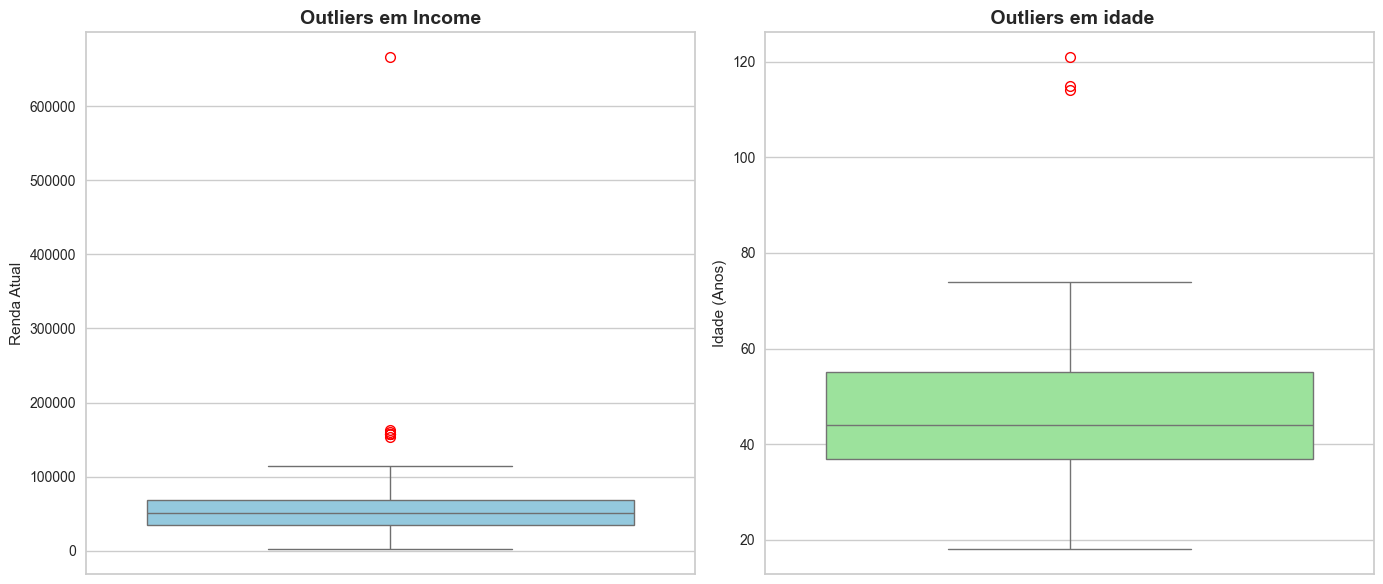

In [22]:
#### Boxplot das colunas 

#Subplots 
fig,axes = plt.subplots(nrows= 1 , ncols= 2, figsize =(14,6))

#Boxplot de renda 
sns.boxplot(data = df, y = 'Income', ax= axes[0], color = 'skyblue', flierprops= {'marker' : 'o', 'markeredgecolor' : 'red'})
axes[0].set_title('Outliers em Income', fontsize=14, fontweight = 'bold')
axes[0].set_ylabel('Renda Atual')

#Boxplot da Idade no segundo espaço (axes[1])
sns.boxplot(data=df, y='Idade', ax=axes[1], color='lightgreen', flierprops= {'marker' : 'o', 'markeredgecolor' : 'red'})
axes[1].set_title(' Outliers em idade', fontsize=14, fontweight = 'bold')
axes[1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()






**Análise**:

### 1. Renda Atual (Income)
* **O Efeito de Esmagamento:**  A caixa azul (que concentra o núcleo da sua base de clientes) está totalmente achatada na parte inferior do gráfico. 
* **O Extremo:** Isso acontece por culpa direta daquele ponto vermelho solitário lá no topo, que ultrapassa a marca dos 600 mil. Ele é tão desproporcional que deforma a escala visual de todos os outros clientes.
* **Outliers Secundários:** Além do caso extremo, há um pequeno agrupamento de pontos vermelhos ali na faixa dos 150 mil a 160 mil. Eles também estão fora do limite saudável (indicado pela linha superior, o "bigode" do gráfico). 

### 2. Idade (Anos)
* **Distribuição Saudável:** Diferente da renda, a caixa verde da idade está bem estruturada e centralizada. Ela nos mostra visualmente que a maior parte do público tem entre 35 e 55 anos, com o limite superior de idade natural batendo ali na casa dos 75 anos.
* **O Erro de Cadastro:** Os três círculos vermelhos isolados acima dos 110 anos (chegando a 120) ficam muito claros. Eles não representam um padrão de consumo, mas sim um erro de preenchimento no sistema de origem (clientes registrados como nascidos no final do século 19).


O melhor cenário possível em uma limpeza de dados se confirmou: **temos anomalias severas, mas em baixíssima quantidade**. 

Se entregassemos esses dados brutos ao K-Means, ele criaria um "cluster de milionários" só para acomodar aquele cliente de 666 mil, desperdiçando um grupo inteiro que poderia ser usado para segmentar os clientes normais. Cortar esses pontos vermelhos cirurgicamente nos garante um algoritmo focado na realidade comercial da empresa, sem perder volume útil de dados.



In [23]:
#Fazemos uma cópia para segurança (boa prática para não perder os dados brutos)
df_limpo = df.copy()


# Método IQR 
for col in colunas_analise:
    Q1 = df_limpo[col].quantile(0.25)
    Q3 = df_limpo[col].quantile(0.75)
    IQR = Q3 - Q1 
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Isolando as linhas que são outliers para visualização
    outliers_coluna = df_limpo[~df_limpo[col].between(limite_inferior, limite_superior)]
    
    print(f'Variável: {col.upper()}')
    print(f'Limite Inferior: {limite_inferior:.2f}')
    print(f'Limite Superior: {limite_superior:.2f}')
    print(f'Foram encontrados {len(outliers_coluna)} outliers nesta coluna')
    
    #Mostrando a tabela com os outliers 
    display(outliers_coluna[['Income', 'Idade']])
    
    #Aplicando o corte: O df_limpo passa a receber apenas os dados DENTRO do limite
    df_limpo = df_limpo[df_limpo[col].between(limite_inferior, limite_superior)]
    
    

#Resumo final fora do loop
print(f"Tamanho original do dataset: {len(df)} linhas")
print(f"Tamanho após limpeza: {len(df_limpo)} linhas")
print(f"Total de linhas removidas: {len(df) - len(df_limpo)}")

Variável: INCOME
Limite Inferior: -14525.50
Limite Superior: 118350.50
Foram encontrados 8 outliers nesta coluna


,Income,Idade
ID,,
8475,157243.0,41
1503,162397.0,38
5555,153924.0,39
1501,160803.0,32
5336,157733.0,43
4931,157146.0,37
11181,156924.0,65
9432,666666.0,37


Variável: IDADE
Limite Inferior: 10.00
Limite Superior: 82.00
Foram encontrados 3 outliers nesta coluna


,Income,Idade
ID,,
7829,36640.0,114
11004,60182.0,121
1150,83532.0,115


Tamanho original do dataset: 2216 linhas
Tamanho após limpeza: 2205 linhas
Total de linhas removidas: 11


#### Colunas Categóricas

In [24]:
#Veriricando valores em Marital Status
df_limpo['Marital_Status'].value_counts()

Marital_Status
Married     854
Together    568
Single      470
Divorced    230
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [25]:
#Verificando valores em Education
df_limpo['Education'].value_counts()

Education
Graduation    1113
PhD            476
Master         364
2n Cycle       198
Basic           54
Name: count, dtype: int64


**Coluna Marital_Status (Estado Civil)**
* **O que vai ser feito:** Reduzir as 8 categorias originais para apenas 2 macro-grupos focados em comportamento de consumo: **"Com Parceiro"** e **"Solteiro"**.
* **Justificativa (O Porquê):**
    * **Comportamento Financeiro:** Para o varejo, clientes casados (`Married`) ou que moram juntos (`Together`) tendem a ter uma renda combinada e padrões de compra familiares semelhantes (compram em maiores volumes). Solteiros, divorciados, viúvos ou pessoas que moram sozinhas (`Alone`) têm um padrão de consumo estritamente individual.
    * **Remoção de Ruído:** O dataset contém dados "lixo" ou preenchimentos não padronizados (como `YOLO` e `Absurd`) que possuem apenas 1 ou 2 registros na base inteira. Se não agruparmos isso, os gráficos ficarão poluídos com categorias minúsculas e irrelevantes.

**Coluna Education (Escolaridade)**
* **O que vai ser feito:** Traduzir os termos e agrupar níveis acadêmicos que são equivalentes (ex: consolidar `2n Cycle` e `Master` na categoria única **"Mestrado"**).
* **Justificativa (O Porquê):**
    * **Redução de Dimensionalidade:** Quanto menos categorias o modelo tiver para processar, mais focado ele será. `2n Cycle` é apenas a nomenclatura do sistema educacional europeu (Processo de Bolonha) para o grau de Mestrado. Manter ambos separados cria uma falsa divisão para o algoritmo.
    * **Clareza Visual:** Na hora de apresentar os resultados, categorias padronizadas, traduzidas e enxutas (`Básico`, `Graduação`, `Mestrado`, `Doutorado`) tornam a Análise Exploratória muito mais limpa e intuitiva para quem vai consumir o relatório.



In [26]:
### Padronizando Marital Status 

#Termos solteiros 
solteiros_termos = ['Single','Divorced','Widow','Alone']
casados_termos = ['Married','Together']

#Condições
condicoes = [df_limpo['Marital_Status'].isin(solteiros_termos),
             df_limpo['Marital_Status'].isin(casados_termos)]

#Escolhas
escolhas = ['Solteiro','Com Parceiro']

#Aplicando no df 
df_limpo['Marital_Status'] = np.select(condicoes, escolhas, default = 'Solteiro')

#Verificando o resultado 
df_limpo['Marital_Status'].value_counts()




Marital_Status
Com Parceiro    1422
Solteiro         783
Name: count, dtype: int64

In [27]:
#### Padronizando Education

#Trocando 2n Cycle e Master para == Mestrado e renomeando outros termos
df_limpo['Education'] = df_limpo['Education'].replace({
    '2n Cycle': 'Mestrado',
    'Master': 'Mestrado',
    'Graduation' : 'Graduação',
    'Basic' : 'Básico',
    'PhD' : 'Doutorado'
})

#Verificando o resultado 
df_limpo['Education'].value_counts()

Education
Graduação    1113
Mestrado      562
Doutorado     476
Básico         54
Name: count, dtype: int64



### Resumo: Data Cleaning & Data Preparation

Para garantir que o algoritmo de clusterização (K-Means) encontre padrões reais e não seja enganado por ruídos, o dataset bruto passou pelas seguintes etapas de tratamento:

**1. Limpeza Estrutural e de Consistência**
* **Tratamento de Nulos:** Remoção das linhas com valores ausentes na coluna `Income` (Renda), que representavam apenas ~1% da base, preservando a integridade estatística do restante.
* **Validação de Duplicatas:** Confirmação de que não havia registros duplicados de clientes.
* **Ajuste de Tipos de Dados:** Conversão da coluna `Dt_Customer` de texto (*string*) para o formato de data (*datetime*).
* **Remoção de Colunas Inúteis:** Exclusão das colunas `Z_CostContact` e `Z_Revenue` (que possuíam variância zero) e transformação do `ID` do cliente no índice do *dataframe*.

**2. Engenharia de Recursos (Feature Engineering)**
Transformamos dados brutos em inteligência de negócio, criando métricas consolidadas:
* `Idade`: Calculada a partir do ano de nascimento (`Year_Birth`).
* `Gasto_Total`: Soma de todos os gastos em categorias de produtos (vinhos, carnes, etc.).
* `Total_Filhos`: Soma de crianças (`Kidhome`) e adolescentes (`Teenhome`).
* `Tempo_Cliente_Dias`: Cálculo da maturidade do cliente na base.
* `Total_Compras`: Consolidação das compras na web, catálogo e loja física.
* **Limpeza de Redundâncias:** Descarte das colunas originais que deram origem a essas novas variáveis para evitar o problema de multicolinearidade (dar "peso duplo" à mesma informação no algoritmo).

**3. Tratamento de Outliers (Anomalias Numéricas)**
* **Diagnóstico:** Utilizamos medidas de tendência central e o cálculo de Assimetria (*Skewness*) para provar matematicamente a existência de valores atípicos severos na Renda (assimetria de 6.76) e na Idade.
* **Corte Cirúrgico (Método IQR):** Aplicamos o Intervalo Interquartil para fatiar do dataset os erros de cadastro (clientes com mais de 110 anos) e pontos fora da curva irreais para o público-alvo (rendas superiores a 600 mil), criando o `df_limpo`.

**4. Padronização de Variáveis Categóricas**
* **Estado Civil (`Marital_Status`):** Limpeza de categorias "lixo" (como *YOLO* e *Absurd*) e consolidação comportamental em apenas dois grandes grupos: **Solteiro** e **Com Parceiro**.
* **Escolaridade (`Education`):** Tradução para o português e agrupamento de nomenclaturas acadêmicas equivalentes (ex: *2n Cycle* e *Master* consolidados como **Mestrado**).


## EDA



#### **Análise Univariada**

**Variáveis Numéricas**

In [28]:
df_limpo.info()

<class 'pandas.DataFrame'>
Index: 2205 entries, 5524 to 9405
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Education                2205 non-null   str    
 1   Marital_Status           2205 non-null   str    
 2   Income                   2205 non-null   float64
 3   Recency                  2205 non-null   int64  
 4   MntWines                 2205 non-null   int64  
 5   MntFruits                2205 non-null   int64  
 6   MntMeatProducts          2205 non-null   int64  
 7   MntFishProducts          2205 non-null   int64  
 8   MntSweetProducts         2205 non-null   int64  
 9   MntGoldProds             2205 non-null   int64  
 10  NumDealsPurchases        2205 non-null   int64  
 11  NumWebPurchases          2205 non-null   int64  
 12  NumCatalogPurchases      2205 non-null   int64  
 13  NumStorePurchases        2205 non-null   int64  
 14  NumWebVisitsMonth        2205 non-nul

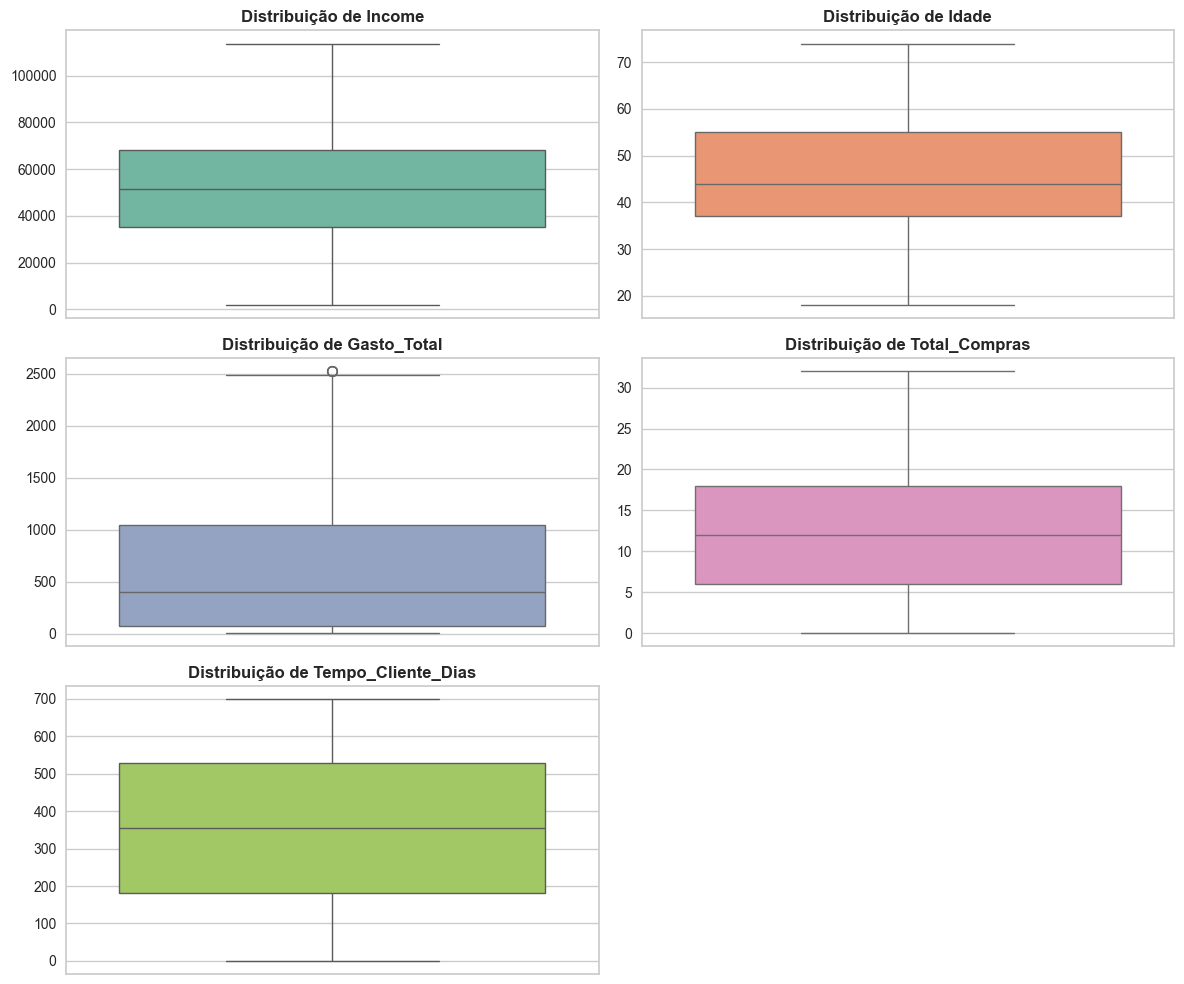

In [29]:
### Medidas de tendencia central

#Selecionando colunas numéricas específicas
num_cols = ['Income','Idade','Gasto_Total','Total_Compras','Tempo_Cliente_Dias']


#Configurando a tela de grade com subplots e colocando a matriz p uma lista simples com flatten
fig, axes = plt.subplots(ncols= 2, nrows= 3, figsize = (12,10))
axes = axes.flatten()
paleta_cores = sns.color_palette('Set2', n_colors=len(num_cols))


#Loop por para cada boxplot
for i, col in enumerate(num_cols):
    #axes[i] garante que o gráfico vá para o quadrante certo
    sns.boxplot(data = df_limpo, y= col, ax= axes[i], color= paleta_cores[i])
    
    #títulos e eixo y
    axes[i].set_title(f'Distribuição de {col}', fontsize = 12, fontweight = 'bold')
    axes[i].set_ylabel('')  #remove o rótulo lateral
    
#Deletar o ultimo espaço já que vai sobrar (5 colunas e 6 espaços)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
    



**Análise técnica de tendência central e dispersão**

### 1. Renda e Idade: O Público Padrão (Distribuições Simétricas)
As linhas centrais dentro das caixas (as Medianas) nos mostram exatamente quem é o cliente típico do negócio:
* **Income (Renda):** A mediana está cravada perto dos **50.000**. A caixa (que concentra 50% dos clientes) vai de aprox. 35k a 68k. A distribuição está perfeitamente simétrica, com os "bigodes" bem equilibrados. Não temos mais milionários distorcendo a base.
* **Idade:** A mediana aponta para **44~45 anos**. Metade do público principal tem entre 38 e 55 anos. Também é uma distribuição muito bem comportada, típica de um público maduro e estabelecido.

### 2. Gasto Total: O Comportamento de Consumo (Assimetria Positiva)
Esse é o gráfico **mais importante para o negócio** e o que tem o comportamento mais distinto:
* **Tendência Central puxada para baixo:**  A linha da mediana está bem baixa (em torno de **400**), muito mais perto do Q1 (percentil 25%) do que do topo da caixa.
* **O que isso significa:** Temos uma forte **Assimetria Positiva** (Right-Skewed). Isso prova que a grande massa de clientes gasta pouco (até 1.000). Porém, o "bigode" superior se estende muito (até 2.500) e até aparece um pontinho isolado ali no topo. Isso nos diz que existe um grupo menor de clientes VIPs que compram em altíssimo volume. O K-Means com certeza vai usar isso para criar um cluster "Premium".

### 3. Engajamento: Compras e Tempo de Casa
* **Total_Compras:** Mediana de **12 compras** por cliente. Distribuição bem simétrica, variando de pouquíssimas compras até cerca de 32 (o máximo saudável).
* **Tempo_Cliente_Dias:** A mediana fica na casa dos **350 dias** (quase 1 ano). A caixa é gigantesca e perfeitamente no meio do gráfico. Isso mostra que você tem uma distribuição muito igualitária entre clientes super novos e clientes muito antigos (que chegam a quase 700 dias de casa).

**Resumo:** Nossos dados numéricos estão no estado da arte. As variáveis de perfil (Idade, Renda, Tempo) são estáveis, o que dará uma fundação sólida para o modelo. A variável de valor (Gasto) é assimétrica, o que é perfeito, pois é exatamente essa "desigualdade" que permite segmentar clientes Prata, Ouro e Diamante.


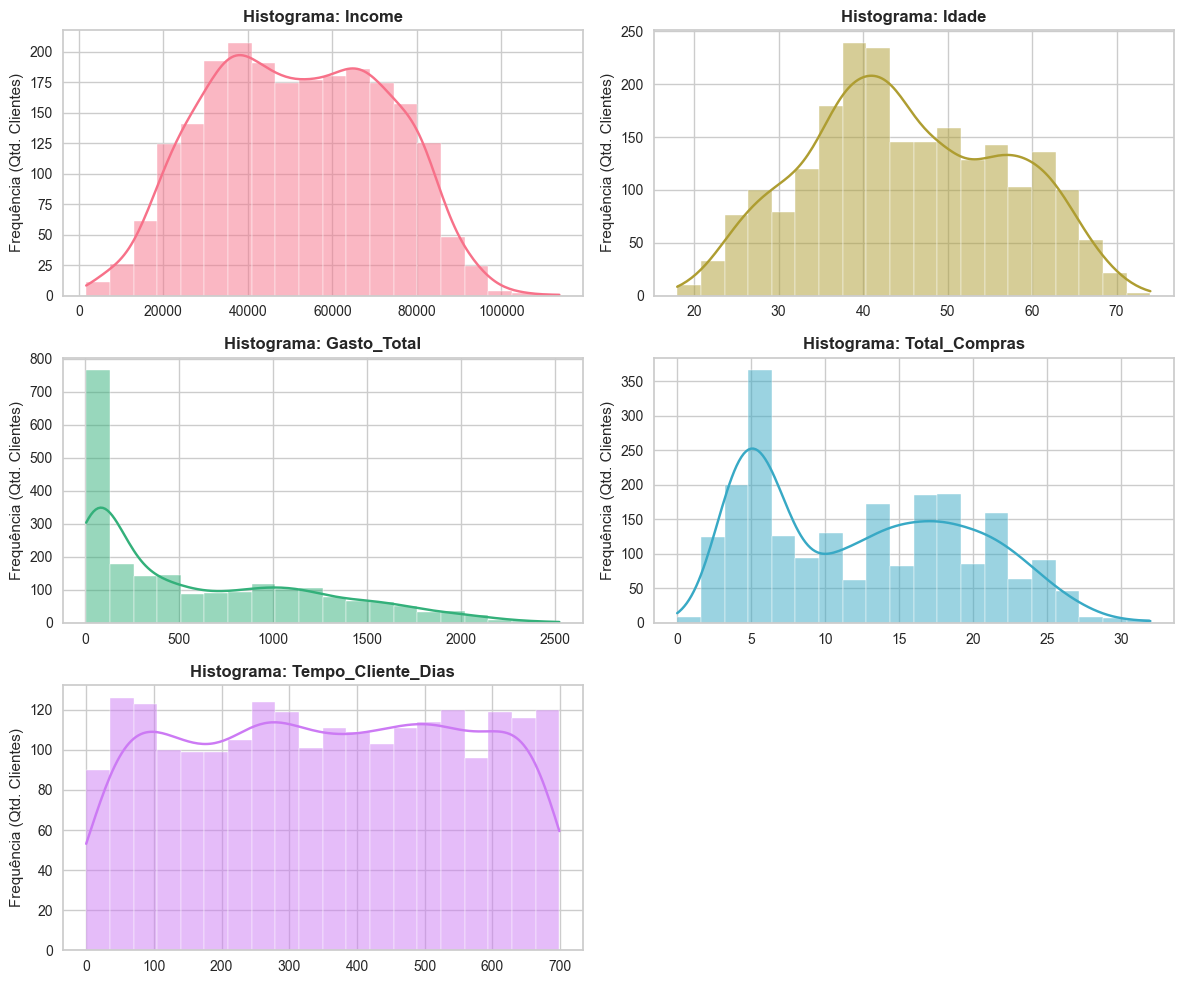

In [30]:


num_cols = ['Income', 'Idade', 'Gasto_Total', 'Total_Compras', 'Tempo_Cliente_Dias']
paleta_cores = sns.color_palette("husl", n_colors=len(num_cols))

#Cria a tela e a grade de espaços fora do loop (3 linhas, 2 colunas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

#Loop para plotar cada Histograma
for i, col in enumerate(num_cols):
    sns.histplot(data=df_limpo, x=col, kde=True, ax=axes[i], color=paleta_cores[i], bins=20)
    
    #Formatando para deixar o gráfico profissional
    axes[i].set_title(f'Histograma: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Frequência (Qtd. Clientes)')
    axes[i].set_xlabel('')

#Deletamos o último espaço vazio
fig.delaxes(axes[5])

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

**Resumo estatístico das distribuições**:

### 1. O Perfil Demográfico: Renda e Idade (Distribuições Normais)
* **Income (Renda - Rosa):** Temos um belo formato de sino (Distribuição Normal). A curva mostra que a esmagadora maioria dos clientes ganha entre 20.000 e 80.000, com um platô muito forte no meio. É uma base com poder aquisitivo super estável e previsível.
* **Idade (Dourado):** Outra distribuição quase normal, com um pico muito claro e acentuado ali na faixa dos 40 anos. A densidade cai suavemente tanto para os mais jovens (20 anos) quanto para os mais velhos (70 anos). O seu cliente "médio" é definitivamente de meia-idade.

### 2. O Comportamento Financeiro: Gasto e Compras (Assimetria e Bimodalidade)
Esses são os gráficos que o K-Means mais vai "gostar" na hora de criar os clusters, pois eles mostram quebras claras de padrão:
* **Gasto_Total (Verde):** Aqui está a nossa **Assimetria Positiva (Right-Skewed)** perfeitamente desenhada. O pico gigantesco à esquerda mostra que a grande massa da base gasta muito pouco (menos de 500). Porém, a "cauda" longa que se arrasta para a direita representa a sua mina de ouro: os clientes premium que gastam 1.500, 2.000 ou mais. O algoritmo certamente usará essa quebra para definir os níveis dos clientes (ex: Bronze, Prata, Ouro).
* **Total_Compras (Azul):** Muito interessante! Essa distribuição tem uma característica **Bimodal** (dois picos). Há um pico agudo de clientes que fazem pouquíssimas compras (ali na marca de 5 a 6). Depois, a curva cai e volta a subir, formando um "morro" mais largo de clientes altamente engajados que compram entre 15 e 22 vezes. 

### 3. A Lealdade: Tempo de Casa (Distribuição Uniforme)
* **Tempo_Cliente_Dias (Lilás):** Como previmos, a curva não forma um sino nem uma cauda; ela forma um "bloco" retangular, o que chamamos de **Distribuição Uniforme**. Isso é um excelente sinal para a saúde do negócio: significa que a empresa adquire novos clientes em um ritmo constante todos os dias, sem depender de "explosões" sazonais de cadastro. Há o mesmo volume de pessoas com 100 dias de casa e com 600 dias de casa.


**Variáveis Categóricas**

In [31]:
### Tranformando variáveis categóricas para o formato 'category'

#Marital Status (não existe nível / hierarquia)
df_limpo['Marital_Status'] = df_limpo['Marital_Status'].astype('category')

#Education (tem nível) vamos organizar em ordem crescente 
ordem_educação = ['Básico','Graduação','Mestrado','Doutorado']

df_limpo['Education'] = pd.Categorical(df_limpo['Education'], categories = ordem_educação, ordered = True)

#Verificando 
df_limpo.info()


<class 'pandas.DataFrame'>
Index: 2205 entries, 5524 to 9405
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Education                2205 non-null   category
 1   Marital_Status           2205 non-null   category
 2   Income                   2205 non-null   float64 
 3   Recency                  2205 non-null   int64   
 4   MntWines                 2205 non-null   int64   
 5   MntFruits                2205 non-null   int64   
 6   MntMeatProducts          2205 non-null   int64   
 7   MntFishProducts          2205 non-null   int64   
 8   MntSweetProducts         2205 non-null   int64   
 9   MntGoldProds             2205 non-null   int64   
 10  NumDealsPurchases        2205 non-null   int64   
 11  NumWebPurchases          2205 non-null   int64   
 12  NumCatalogPurchases      2205 non-null   int64   
 13  NumStorePurchases        2205 non-null   int64   
 14  NumWebVisitsMonth    

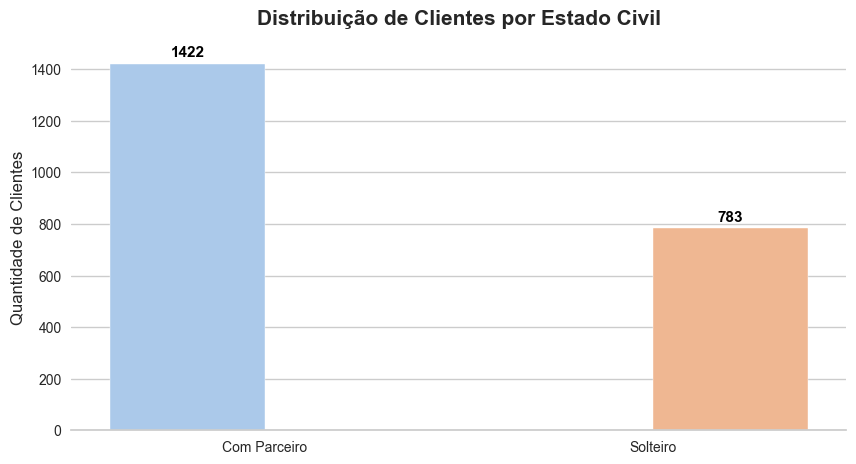

In [32]:
#Countplot Estado Civil
plt.figure(figsize=(10, 5))

ax1 = sns.countplot( data=df_limpo, x='Marital_Status', palette='pastel',hue='Marital_Status', legend=False)

ax1.set_title('Distribuição de Clientes por Estado Civil', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Quantidade de Clientes', fontsize=12)
ax1.set_xlabel('')

#Colocando os números nas barras diretamente
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontweight='bold', color='black', fontsize=11)

sns.despine(left=True)
plt.show()

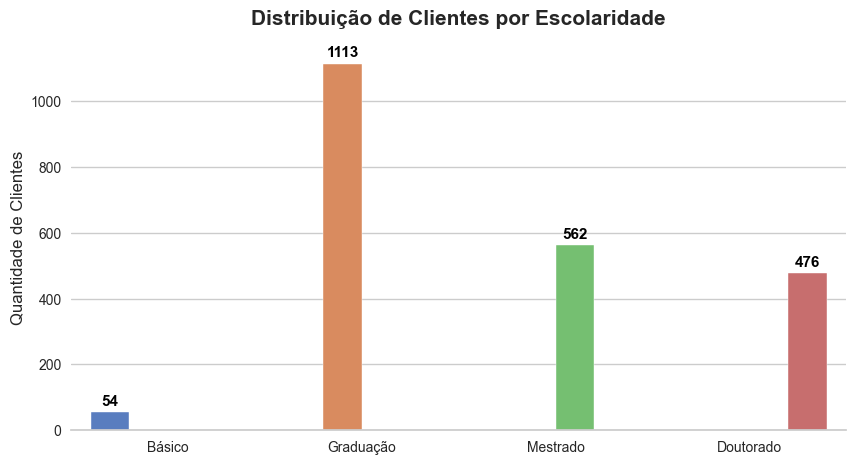

In [33]:
#Count plot Escolaridade 
plt.figure(figsize=(10, 5))

ax2 = sns.countplot(data=df_limpo, x='Education', palette='muted',hue='Education', legend=False)

ax2.set_title('Distribuição de Clientes por Escolaridade', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel('Quantidade de Clientes', fontsize=12)
ax2.set_xlabel('')

#Colocando os números nas barras diretamente
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fontweight='bold', color='black', fontsize=11)

sns.despine(left=True)
plt.show()

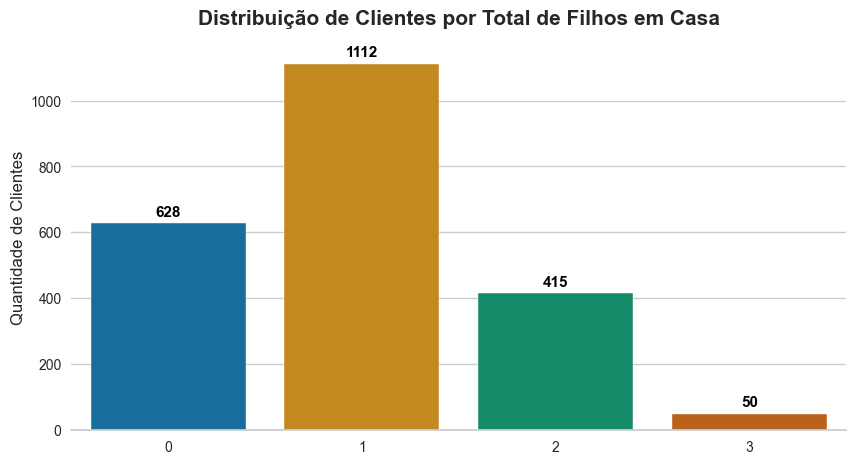

In [34]:
#Countplot Quantidade Total de Filhos 
plt.figure(figsize=(10, 5))

ax3 = sns.countplot(data=df_limpo, x='Total_Filhos', palette='colorblind',hue='Total_Filhos', legend=False)

ax3.set_title('Distribuição de Clientes por Total de Filhos em Casa', fontsize=15, fontweight='bold', pad=15)
ax3.set_ylabel('Quantidade de Clientes', fontsize=12)
ax3.set_xlabel('')

#Colocando os números nas barras diretamente
for container in ax3.containers:
    ax3.bar_label(container, padding=3, fontweight='bold', color='black', fontsize=11)

sns.despine(left=True)
plt.show()

### Perfil Demográfico e Comportamental (Análise Categórica)

**1. Estado Civil: Forte apelo familiar**
A base de clientes é amplamente dominada por pessoas **Com Parceiro** (1.422 registros), representando quase o dobro do público **Solteiro** (783). 
* **Insight de Negócio:** O perfil de consumo é predominantemente voltado para casais ou núcleos familiares. Campanhas de marketing focadas em "momentos a dois", jantares harmonizados ou kits tamanho família terão uma taxa de conversão muito maior do que abordagens focadas em consumo estritamente individual.

**2. Escolaridade: Público altamente qualificado**
Estamos lidando com uma base de consumidores extremamente instruída. A esmagadora maioria possui ensino superior completo (**Graduação**: 1.113), e uma parcela quase equivalente possui pós-graduação (**Mestrado** e **Doutorado** somam 1.038 clientes). O nível Básico é praticamente inexistente (54 clientes).
* **Insight de Negócio:** Esse alto nível educacional confirma que a empresa lida com um consumidor mais sofisticado e exigente. A linguagem das campanhas pode (e deve) ser mais refinada, com descrições detalhadas sobre a origem dos produtos (como notas de degustação de vinhos e cortes nobres de carne).

**3. Composição Familiar: Orçamento disponível para luxos**
O formato familiar padrão desta base é de **1 filho** em casa (1.112 clientes), seguido por residências **sem filhos** (628). Famílias grandes (3 filhos) representam a absoluta minoria (apenas 50).
* **Insight de Negócio:** Famílias menores ou casais sem filhos tendem a ter uma fatia maior de *Renda Discricionária* (dinheiro livre após pagar as contas essenciais). É exatamente esse perfil que consome itens *premium* do varejo, o que explica o sucesso da empresa na venda de vinhos e carnes.



#### Análise Bivariada

**Variáveris numericas**

In [35]:
#Matriz de correlaçao
matrix_correlation = df[num_cols].corr()
matrix_correlation

,Income,Idade,Gasto_Total,Total_Compras,Tempo_Cliente_Dias
Income,1.000000,0.161791,0.667576,0.625755,-0.018531
Idade,0.161791,1.000000,0.113487,0.165397,-0.020305
Gasto_Total,0.667576,0.113487,1.000000,0.822948,0.158577
Total_Compras,0.625755,0.165397,0.822948,1.000000,0.163802
Tempo_Cliente_Dias,-0.018531,-0.020305,0.158577,0.163802,1.000000


<Axes: >

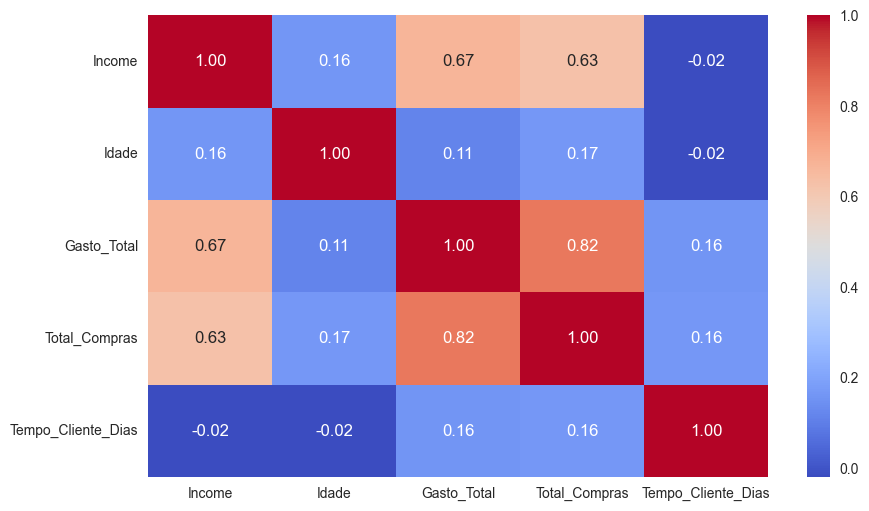

In [36]:
#Heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(matrix_correlation, annot = True, cbar = True, cmap = 'coolwarm', fmt = '.2f', linecolor= 'black')

### Análise Bivariada: Matriz de Correlação (Pearson)

Ao analisar as relações lineares entre as variáveis numéricas do comportamento dos clientes, três grandes descobertas se destacam:

**1. O Motor Financeiro: Renda dita o ritmo de consumo (Forte Correlação)**
* Existe uma correlação positiva forte entre a Renda (`Income`) e o Gasto Total (`0.67`), bem como entre a Renda e o Total de Compras (`0.63`). 
* **Insight de Negócio:** Isso prova matematicamente o óbvio que o negócio precisa ouvir: o poder aquisitivo é o fator número um que impulsiona o faturamento. Campanhas focadas em clientes de alta renda têm probabilidade altíssima de retorno em volume de dinheiro e em quantidade de transações.

**2. A Relação Lógica: Frequência vs. Valor (Correlação Altíssima)**
* O cruzamento entre Total de Compras e Gasto Total apresenta a correlação mais forte do painel (`0.82`). 
* **Insight de Negócio:** Quem compra mais vezes, também deixa mais dinheiro no fim do dia. Isso indica que a estratégia de "fidelização por recorrência" (fazer o cliente voltar mais vezes) é extremamente eficiente para aumentar o Ticket Médio Anual.

**3. As "Não-Correlações" (Insights Contraintuitivos)**
Na Ciência de Dados, a falta de correlação é uma descoberta tão valiosa quanto uma correlação forte.
* **Idade (Neutro):** A idade possui correlações baixíssimas com o Gasto (`0.11`) e com a Renda (`0.16`). Isso significa que ser mais velho na sua base não se traduz em gastar mais. O foco das campanhas premium deve ser na faixa de renda, e não na faixa etária.
* **Tempo de Casa (Oportunidade de Melhoria):** O tempo que o cliente está na base (`Tempo_Cliente_Dias`) tem correlação praticamente zero (`-0.02` e `0.16`) com todas as variáveis financeiras.
* **Insight de Negócio:** A lealdade (tempo) não está se revertendo em aumento de ticket. Clientes antigos gastam o mesmo que clientes novos. Há uma grande oportunidade para a equipe de CRM criar programas de fidelidade que recompensem e estimulem os clientes mais antigos a aumentarem o seu volume de compras.


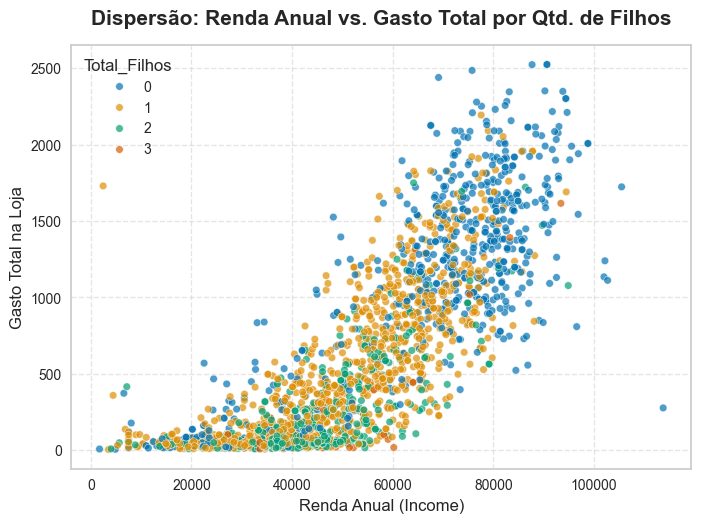

In [37]:
#Scatterplot Income x Gasto total 
sns.scatterplot(data= df_limpo, x = 'Income', y= 'Gasto_Total', alpha = 0.7, s=30, palette = 'colorblind', hue = 'Total_Filhos')

#Titulos e eixos
plt.title('Dispersão: Renda Anual vs. Gasto Total por Qtd. de Filhos', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Gasto Total na Loja', fontsize=12)
plt.xlabel('Renda Anual (Income)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Análise Bivariada: A Matriz de Consumo (Renda vs. Gasto vs. Filhos)

O cruzamento simultâneo entre Renda, Gasto Total e Composição Familiar revela o comportamento mais importante do nosso banco de dados. A nuvem de pontos forma um "cone" que se abre conforme a renda aumenta, mas a altura que o cliente atinge nesse cone é estritamente definida pelo número de filhos:

**1. O Teto de Gastos (0 Filhos - Pontos Azuis):**
Observe como os pontos azuis dominam quase que exclusivamente o topo do gráfico. Clientes sem filhos têm a maior *Renda Discricionária*. Quando eles ultrapassam a faixa dos 50.000 de renda, o gasto decola rapidamente, ultrapassando facilmente a marca de 1.500 a 2.000. **Eles são o seu público Premium.**

**2. A Zona de Transição (1 Filho - Pontos Laranjas):**
Eles formam o "recheio" da nuvem. O gasto cresce com a renda, mas o peso de um filho já funciona como uma "âncora" natural, limitando o teto de gastos na loja. Um cliente com 1 filho e renda de 80.000 dificilmente gasta o mesmo que um cliente sem filhos com a mesma renda.

**3. O Piso de Gastos (2 ou 3 Filhos - Pontos Verdes e Vermelhos):**
Aqui está o maior insight de negócio. Olhe para a base da nuvem na faixa da direita (Renda alta, entre 60k e 80k). Ela é densamente povoada por pontos verdes e vermelhos. Isso prova que **mesmo ganhando muito bem, famílias grandes gastam pouco (geralmente menos de 800) neste negócio.** O dinheiro deles está comprometido com outras prioridades familiares (escola, saúde, etc.), e não com os produtos premium da sua loja (vinhos e carnes nobres).



Tabela de Contingência (em %):


Total_Filhos,0,1,2,3
Marital_Status,,,,
Com Parceiro,26.5,51.9,19.4,2.2
Solteiro,32.1,47.8,17.8,2.4


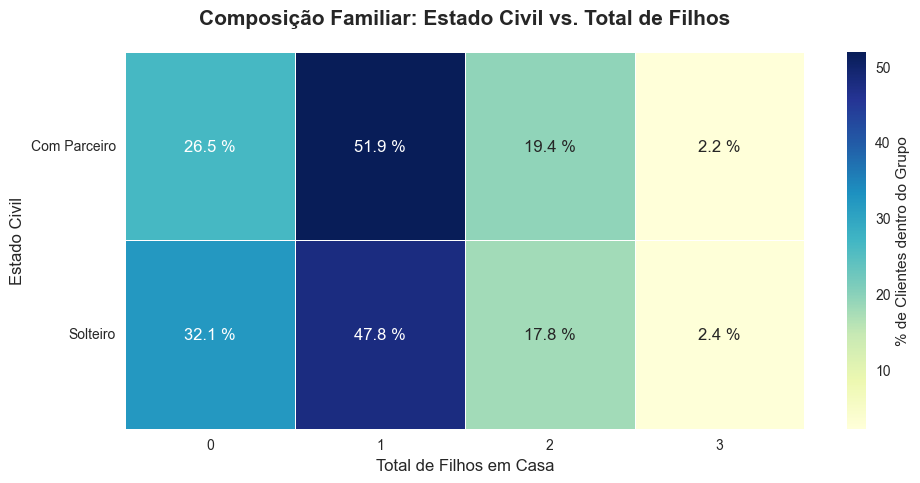

In [38]:

#Gerando a Tabela de Contingência Relativa (Percentual)
tabela_contingencia = pd.crosstab(
    df_limpo['Marital_Status'], 
    df_limpo['Total_Filhos'], 
    normalize='index' #calcula a %
) * 100

print("Tabela de Contingência (em %):")
display(tabela_contingencia.round(1))

#Plotando a Tabela como um Heatmap para o relatório
plt.figure(figsize=(10, 5))

ax = sns.heatmap(
    tabela_contingencia, 
    annot=True,          
    fmt=".1f",           
    cmap="YlGnBu",       
    linewidths=0.5,
    cbar_kws={'label': '% de Clientes dentro do Grupo'}
)

#Adicionando o símbolo de % nos números dentro dos quadrados
for t in ax.texts:
    t.set_text(t.get_text() + " %")

plt.title('Composição Familiar: Estado Civil vs. Total de Filhos', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Estado Civil', fontsize=12)
plt.xlabel('Total de Filhos em Casa', fontsize=12)


plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

### Análise Estado Civil x Total de filhos:

O cruzamento percentual entre o Estado Civil e a Quantidade de Filhos revela que a estrutura familiar dos clientes foge dos estereótipos tradicionais, trazendo insights fundamentais para a segmentação de campanhas:

**1. A Quebra do Mito "Solteiro = Sem Filhos"**
A descoberta mais impactante deste painel é que a esmagadora maioria dos clientes solteiros **possui filhos**. Quase metade deles (47.8%) tem 1 filho em casa, e apenas 32.1% são, de fato, solteiros sem filhos. 
* **Insight de Negócio:** A equipe de marketing não pode tratar o grupo "Solteiro" como um bloco único focado em consumo individual e luxo. Um solteiro com 1 ou 2 filhos tem o orçamento tão engessado quanto um casal na mesma situação.

**2. O Padrão Ouro: Famílias Pequenas**
Independentemente de serem casados ou solteiros, o padrão absoluto de consumo desta base é a família de **1 filho** (representando mais de 50% dos clientes "Com Parceiro" e quase 48% dos "Solteiros"). Famílias grandes (3 filhos) são estatisticamente irrelevantes em ambos os grupos (na casa dos 2%).

**3. A Validação Final para o Machine Learning**
Lembra que no nosso gráfico de dispersão anterior descobrimos que quem não tem filhos (0) gasta muito mais? 
Olhando para este mapa de calor, vemos que o grupo de "0 filhos" está bem distribuído entre Casados (26.5%) e Solteiros (32.1%). 
* **O Veredito:** Isso prova matematicamente que a verdadeira "alavanca" que destrava o alto consumo não é o fato do cliente ter um parceiro ou não, mas sim **a ausência de filhos**. 




# 📌 Conclusão da Análise Exploratória (EDA)

Após um rigoroso processo de limpeza (*Data Cleaning*), tratamento de outliers e exploração estatística univariada e bivariada, mapeamos com sucesso o DNA do nosso consumidor. Os dados nos contam uma história clara sobre quem é o cliente e, mais importante, o que o faz abrir a carteira.

### 1. O Perfil Demográfico: Maduros, Instruídos e Familiares
O cliente "típico" desta base é maduro (mediana de 44-45 anos) e possui um altíssimo nível de escolaridade, com a esmagadora maioria ostentando diplomas de Graduação, Mestrado ou Doutorado. 
* O mito do "solteiro sem filhos" foi quebrado: a estrutura familiar padrão do nosso negócio, independentemente do estado civil, é a de **famílias pequenas (com 1 filho em casa)**. Famílias numerosas (3 filhos) são raras no nosso ecossistema.

### 2. O Comportamento Financeiro: A Regra de Pareto e a Assimetria
A distribuição da Renda (`Income`) é altamente saudável e simétrica (focada na faixa dos 50.000). No entanto, o `Gasto_Total` apresenta uma forte assimetria positiva. 
* **O que isso significa:** A maior parte da base gasta pouco de forma conservadora, mas existe um nicho de clientes VIPs com altíssimo volume de compras (formando uma cauda longa no gráfico). É neste nicho que mora o lucro da operação.

### 3. A Descoberta de Ouro: Renda vs. Filhos
A correlação mais forte do negócio é, sem surpresas, entre Renda e Gasto (`0.67`). Contudo, a análise visual bivariada provou que a renda é apenas *metade* da equação. 
* A verdadeira "alavanca" de consumo de produtos premium no nosso varejo é a ausência de dependentes. **A Renda destrava o potencial de gasto, mas a Quantidade de Filhos define o teto.** Clientes de alta renda sem filhos gastam facilmente o dobro ou o triplo de clientes com a mesma renda, mas que possuem 2 ou 3 filhos.

### 4. Oportunidades de Negócio (CRM)
Descobrimos "não-correlações" cruciais: a idade do cliente não afeta o quanto ele gasta, e incrivelmente, **o tempo de casa também não**. Clientes antigos e leais estão gastando o mesmo volume que clientes novos. Isso evidencia uma grande oportunidade para a criação de programas de fidelidade que recompensem o aumento do *Ticket Médio*.



**Padronização de Variáveis Categórcicas**

In [39]:
#Criamos um DataFrame novo exclusivo para o Machine Learning, assim, preservamos o df_limpo intacto se precisarmos voltar atrás
df_ml = df_limpo.copy()

###Coluna Education (existe nível hierárquico - label encoder)

#Criar dicinário para a coluna Education por nível hierarquico
df_ml['Education'] = df_ml['Education'].map({'Básico' : 0,
                                'Graduação' : 1,
                                'Mestrado' : 2,
                                'Doutorado' : 3}
 )


In [40]:
###Coluna Marital Status não existe nível hierárquico (one hot encoding)
encoder = OneHotEncoder(drop = 'first', sparse_output= False, dtype = int) #drop = 'first' evita multicolinearidade e sparse garante um array normal

#Treinando o modelo 
encodede_data = encoder.fit_transform(df_ml[['Marital_Status']])

#Resgatando os nomes das novas colunas geradas 
encoded_cols = encoder.get_feature_names_out(['Marital_Status'])

In [41]:
#Trnaformando o array de voltam em um df 
df_encoded = pd.DataFrame(encodede_data, columns = encoded_cols, index = df_ml.index)

#Juntando as novas colunas do df_ml orignal e excluindo a antiga em texto
df_ml = pd.concat([df_ml.drop('Marital_Status', axis = 1), df_encoded], axis = 1)

#Vendo os resultados
# Dando uma espiada no resultado
print("Novo formato dos dados:")
display(df_ml.head())

Novo formato dos dados:


,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,NumStorePurchases,NumWebVisitsMonth,Complain,Idade,Gasto_Total,Total_Filhos,Tempo_Cliente_Dias,Total_Compras,Total_Campanhas_Aceitas,Marital_Status_Solteiro
ID,,,,,,,,,,,,,,,,,,,,,
5524,1,58138.0,58,635,88,546,172,88,88,3,...,4,7,0,57,1617,0,663,22,1,1
2174,1,46344.0,38,11,1,6,2,1,6,2,...,2,5,0,60,27,2,113,4,0,1
4141,1,71613.0,26,426,49,127,111,21,42,1,...,10,4,0,49,776,0,312,20,0,0
6182,1,26646.0,26,11,4,20,10,3,5,2,...,4,6,0,30,53,1,139,6,0,0
5324,3,58293.0,94,173,43,118,46,27,15,5,...,6,5,0,33,422,1,161,14,0,0


**Padronização variáveis numéricas**

In [45]:
#Vamos padronizar nossas var. num. com Standart Scaler ( média = 0 e std = 1)
scaler = StandardScaler()

#Treinando e e aplicando o transform no df_ml (ele devolve uma matriz sem os nomes das colunas)
scaler_data = scaler.fit_transform(df_ml)

#Colocamos de volta no df_ml com o nome das colunas 
df_ml_padronizado = pd.DataFrame(scaler_data, columns  = df_ml.columns, index = df_ml.index)

In [46]:
#Verificando se a média ficou muito perto de 0 e o desvio padrão 1
print("Estatísticas após o StandardScaler (Média = 0, Desvio Padrão = 1):")
display(df_ml_padronizado.describe().round(2).loc[['mean', 'std']])

Estatísticas após o StandardScaler (Média = 0, Desvio Padrão = 1):


,Education,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,NumStorePurchases,NumWebVisitsMonth,Complain,Idade,Gasto_Total,Total_Filhos,Tempo_Cliente_Dias,Total_Compras,Total_Campanhas_Aceitas,Marital_Status_Solteiro
mean,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Modelling

**Elbow Method**

In [47]:
### Criando o método do cotovelo para avaliação de número de clusters 

#Lista vazia 
inertia = []

#Intervalo de classes de 1 a 0
k_valores = range(1,11)

#Loop for para iterar 
for k in k_valores:
    #Instanciamos o modelo para k de cada rodada
    kmeans = KMeans(n_clusters= k, random_state= 42, n_init= 'auto') #padrão das novas versões
    kmeans.fit(df_ml_padronizado)
    
    #Aqui extrairmos a inercia e colocamos o resulado na lista
    inertia.append(kmeans.inertia_)
    
    

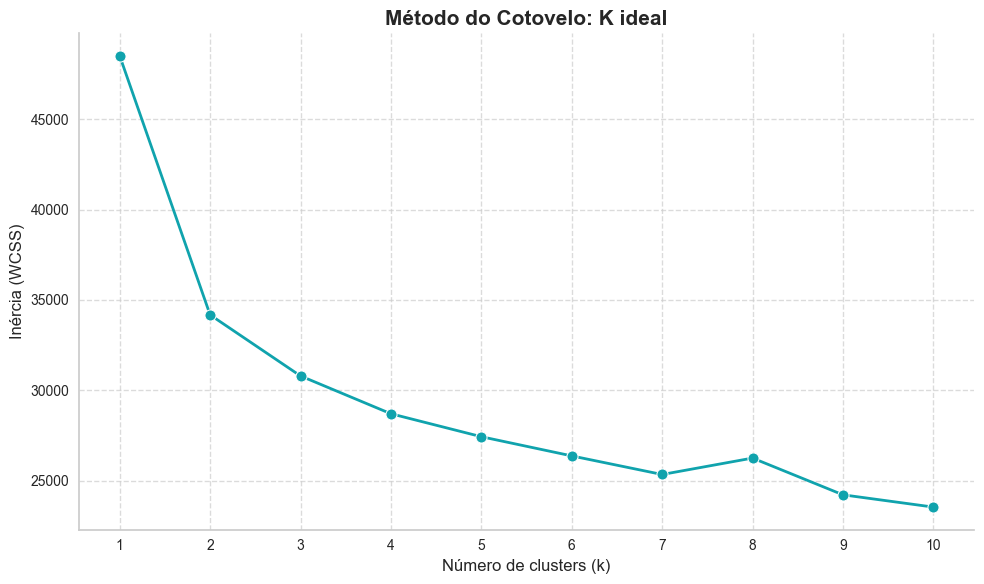

In [50]:
#Gráfico de Elbow
plt.figure(figsize=(10,6))

#Plotando linha para marcar cada numero de k 
sns.lineplot(x = k_valores, y= inertia, marker = 'o', color ="#10A3AD", linewidth=2, markersize=8) 

#Títulos e eixos
plt.title('Método do Cotovelo: K ideal', fontsize = 15, fontweight = 'bold')
plt.xlabel('Número de clusters (k)', fontsize = 12)
plt.ylabel('Inércia (WCSS)', fontsize = 12)

plt.xticks(k_valores)

#Adicionando linhas de grade 
plt.grid(True, linestyle = '--', alpha = 0.7)
sns.despine()

plt.tight_layout()
plt.show()


### Análise do Gráfico

O objetivo deste gráfico é encontrar o ponto de "retorno decrescente", ou seja, o momento em que adicionar mais um grupo (cluster) para a equipe de marketing não melhora significativamente a separação matemática dos clientes.

Lendo a linha:
1. **A Queda Livre (k=1 para k=2):** A Inércia despenca de ~48.000 para ~34.000. O ganho matemático ao separar os clientes em 2 grupos é gigantesco.
2. **A Desaceleração (k=2 para k=3 e k=4):** A linha continua caindo num ritmo forte para o 3 (~31.000) e para o 4 (~28.500).
3. **A Estabilização (A partir de k=4):** Do cluster 4 em diante, a linha começa a deitar. A descida do 4 para o 5, do 5 para o 6, etc., é muito mais suave. A curva vira praticamente uma reta descendente (o "antebraço" do cotovelo).

**Com isso:**
O nosso "cotovelo" perfeito (o ponto de flexão mais evidente antes da estabilização) está **entre o 3 e o 4**. 

**O Veredito de Negócios:**
Para o varejo, trabalhar com 4 clusters é um "número de ouro". Geralmente, ele permite segmentar os clientes da seguinte forma:
* Os VIPs (Alta renda, gastam muito).
* Os Promissores (Alta renda, mas gastam pouco - nosso alvo de campanha!).
* Os Regulares (Renda média, gasto médio).
* Os Sensíveis a Preço (Renda baixa, gasto baixo).

Se usarmos apenas 2, a análise fica muito generalista. Se usarmos 8, a equipe de marketing enlouquece tentando criar 8 campanhas diferentes.


In [56]:
print("Calculando PCA para 2 Dimensões")

pca_2d = PCA(n_components=2, random_state=42)
dados_pca_2d = pca_2d.fit_transform(df_ml_padronizado)

#Convertemos a matriz NumPy resultante de volta num DataFrame do Pandas
df_pca_2d = pd.DataFrame(
    dados_pca_2d,
    columns=['Componente_1', 'Componente_2'], 
    index=df_ml_padronizado.index
)

#Quanta informação (variância) mantivemos em 2D
variancia_2d = pca_2d.explained_variance_ratio_
print(f'Variância mantida no Componente 1: {variancia_2d[0]:.2%}')
print(f'Variância mantida no Componente 2: {variancia_2d[1]:.2%}')
print(f'TOTAL DE INFORMAÇÃO RETIDA EM 2D: {np.sum(variancia_2d):.2%}')
print('\nExemplo dos dados comprimidos em 2D:')
display(df_pca_2d.head())


Calculando PCA para 2 Dimensões
Variância mantida no Componente 1: 37.04%
Variância mantida no Componente 2: 9.28%
TOTAL DE INFORMAÇÃO RETIDA EM 2D: 46.32%

Exemplo dos dados comprimidos em 2D:


,Componente_1,Componente_2
ID,,
5524,4.579567,0.656812
2174,-2.872330,-0.771832
4141,2.066822,-0.303950
6182,-2.822214,-1.152983
5324,-0.153156,0.472998


In [57]:
print('Calculando PCA para 3 Dimensões')

pca_3d = PCA(n_components=3, random_state=42)
dados_pca_3d = pca_3d.fit_transform(df_ml_padronizado)

df_pca_3d = pd.DataFrame(
    dados_pca_3d,
    columns=['Componente_1', 'Componente_2', 'Componente_3'],
    index=df_ml_padronizado.index
)

#Quanta informação (variância) mantivemos em 3D
variancia_3d = pca_3d.explained_variance_ratio_
print(f'Variância mantida no Componente 1: {variancia_3d[0]:.2%}')
print(f'Variância mantida no Componente 2: {variancia_3d[1]:.2%}')
print(f'Variância mantida no Componente 3: {variancia_3d[2]:.2%}')
print(f'TOTAL DE INFORMAÇÃO RETIDA EM 3D: {np.sum(variancia_3d):.2%}')
print('\nExemplo dos dados comprimidos em 3D:')
display(df_pca_3d.head())

Calculando PCA para 3 Dimensões
Variância mantida no Componente 1: 37.04%
Variância mantida no Componente 2: 9.28%
Variância mantida no Componente 3: 6.50%
TOTAL DE INFORMAÇÃO RETIDA EM 3D: 52.82%

Exemplo dos dados comprimidos em 3D:


,Componente_1,Componente_2,Componente_3
ID,,,
5524,4.579567,0.656812,-2.086003
2174,-2.872330,-0.771832,0.964538
4141,2.066822,-0.303950,-0.092497
6182,-2.822214,-1.152983,-0.454216
5324,-0.153156,0.472998,0.717449



### Resumo dos Resultados do PCA
* **PCA 2D:** Reteve **46,32%** da informação (variância) original.
* **PCA 3D:** Reteve **52,82%** da informação (variância) original.

### Por que vamos usar o dataset original (7 dimensões) no K-Means:
* **A Perda de Informação:** Como a retenção ficou em torno de 50%, reduzir nossos dados para 2 ou 3 dimensões significa "jogar fora" quase metade das nuances de comportamento dos clientes. O comportamento de consumo desta base é complexo e depende de múltiplas variáveis atuando juntas.
* **A Precisão Matemática:** Algoritmos como o K-Means lidam perfeitamente com múltiplas dimensões. Para garantir que os agrupamentos sejam os mais precisos e reais possíveis, vamos treinar o modelo usando as **7 colunas originais padronizadas**, permitindo que o K-Means tome decisões com 100% da informação disponível.
* **O Papel do PCA:** Usaremos os resultados do PCA **exclusivamente para a visualização**. 